# SDG 13 Climate Action: Why Some Countries Reduce CO2 Faster

**Problem statement:** What are the conditions relating to effective emission reduction, and which nations seem to be following a better SDG 13 pathway?

In [1]:
import warnings
warnings.filterwarnings('ignore')

import numpy as np
import pandas as pd
import plotly.express as px
import plotly.graph_objects as go

pd.set_option('display.max_columns', 200)
pd.set_option('display.float_format', lambda x: f'{x:,.3f}')

## 1) Data Loading


In [2]:
OWID_PATH = 'owid-co2-data.csv'
ENERGY_PATH = 'global-data-on-sustainable-energy (1).csv'

owid_raw = pd.read_csv(OWID_PATH)
energy_raw = pd.read_csv(ENERGY_PATH)

print('OWID shape:', owid_raw.shape, '| Energy shape:', energy_raw.shape)
print('Analysis window candidates:', int(max(owid_raw['year'].min(), energy_raw['Year'].min())), '-', int(min(owid_raw['year'].max(), energy_raw['Year'].max())))

OWID shape: (50411, 79) | Energy shape: (3649, 21)
Analysis window candidates: 2000 - 2020


## 2) Cleaning and Merge Consistency

Missing value strategy used:
- Country-wise interpolation for time-dependent variables (preserves trend continuity).
- Median fallback for remaining sparse gaps (ensures model/visual comparability).
- Countries with insufficient CO2 history are excluded from success labeling to avoid unstable rankings.


In [3]:
def standardize_country_names(df, col):
    mapping = {
        'United States of America': 'United States',
        'Russian Federation': 'Russia',
        'Viet Nam': 'Vietnam',
        'Iran (Islamic Republic of)': 'Iran',
        'Syrian Arab Republic': 'Syria',
        'Republic of Korea': 'South Korea',
        "Democratic People's Republic of Korea": 'North Korea',
        'Democratic Republic of the Congo': 'Democratic Republic of Congo',
        'Czech Republic': 'Czechia',
        'Turkiye': 'Turkey',
        'United Republic of Tanzania': 'Tanzania',
        'Bolivia (Plurinational State of)': 'Bolivia',
        'Venezuela (Bolivarian Republic of)': 'Venezuela',
        "Lao People's Democratic Republic": 'Laos',
        'Brunei Darussalam': 'Brunei',
        'Cabo Verde': 'Cape Verde',
        'Moldova, Republic of': 'Moldova',
        'Timor-Leste': 'East Timor'
    }
    out = df.copy()
    out[col] = out[col].replace(mapping)
    return out


def add_region(df):
    region_map = px.data.gapminder()[['country', 'continent']].drop_duplicates().rename(columns={'continent': 'region'})
    out = df.merge(region_map, on='country', how='left')
    fallback = {'Kosovo': 'Europe', 'South Sudan': 'Africa', 'World': 'Other'}
    out['region'] = out['region'].fillna(out['country'].map(fallback)).fillna('Other')
    return out


def prepare_dataset(owid_df, energy_df, start_year=2000, end_year=2022):
    owid = owid_df.copy()
    energy = energy_df.copy()

    energy = energy.rename(columns={
        'Entity': 'country',
        'Year': 'year',
        'Renewable energy share in the total final energy consumption (%)': 'renewable_energy_share_pct',
        'Primary energy consumption per capita (kWh/person)': 'energy_consumption_pc_energy',
        'Energy intensity level of primary energy (MJ/$2017 PPP GDP)': 'energy_intensity_mj_per_gdp',
        'Value_co2_emissions_kt_by_country': 'co2_kt_energy_dataset'
    })

    owid = standardize_country_names(owid, 'country')
    energy = standardize_country_names(energy, 'country')

    # Filter to meaningful analysis window.
    # Convert iso_code to string to handle mixed types (str + NaN floats)
    owid['iso_code'] = owid['iso_code'].astype(str)
    owid = owid[
        owid['iso_code'].notna()
        & (owid['iso_code'].str.len() == 3)
        & (~owid['iso_code'].str.startswith('OWID'))
        & (owid['year'].between(start_year, end_year))
    ].copy()

    energy = energy[energy['year'].between(start_year, end_year)].copy()

    # Ensure one record per country-year before merging.
    owid = owid.sort_values(['country', 'year']).drop_duplicates(['country', 'year'], keep='last')
    energy = energy.sort_values(['country', 'year']).drop_duplicates(['country', 'year'], keep='last')

    energy_cols = [
        'country', 'year',
        'renewable_energy_share_pct',
        'energy_consumption_pc_energy',
        'energy_intensity_mj_per_gdp',
        'gdp_per_capita',
        'gdp_growth',
        'Access to electricity (% of population)',
        'Low-carbon electricity (% electricity)'
    ]
    energy_cols = [c for c in energy_cols if c in energy.columns]

    # Validate merge cardinality to enforce consistency.
    df = owid.merge(energy[energy_cols], on=['country', 'year'], how='left', validate='1:1')

    numeric_cols = [
        'co2', 'co2_per_capita', 'population', 'gdp',
        'energy_per_capita', 'renewable_energy_share_pct',
        'energy_intensity_mj_per_gdp', 'gdp_per_capita',
        'energy_consumption_pc_energy', 'primary_energy_consumption'
    ]
    for c in numeric_cols:
        if c in df.columns:
            df[c] = pd.to_numeric(df[c], errors='coerce')

    # Keep countries with enough historical CO2 signal.
    counts = df.groupby('country')['co2'].count().reset_index(name='n')
    keep = counts[counts['n'] >= 10]['country']
    df = df[df['country'].isin(keep)].copy()

    # Time-aware imputation.
    interp_cols = [c for c in numeric_cols if c in df.columns]
    df = df.sort_values(['country', 'year']).copy()
    df[interp_cols] = df.groupby('country')[interp_cols].transform(lambda x: x.interpolate(limit_direction='both'))

    # Median fallback for residual missing values.
    for c in interp_cols:
        df[c] = df[c].fillna(df[c].median())

    df = add_region(df)
    return df


df = prepare_dataset(owid_raw, energy_raw, start_year=2000, end_year=2022)
latest_year = int(df['year'].max())
latest_df = df[df['year'] == latest_year].copy()

print('Prepared shape:', df.shape)
print('Countries:', df['country'].nunique())
print('Years:', int(df['year'].min()), '-', int(df['year'].max()))

Prepared shape: (5681, 87)
Countries: 247
Years: 2000 - 2022


## 3) Feature Engineering and Success Definition


In [4]:
# Requested engineered variables

df = df.sort_values(['country', 'year']).copy()

# CO2 emission change (%) per country over time
df['co2_change_pct'] = df.groupby('country')['co2'].pct_change() * 100

# Renewable energy share (%) with fallback
df['renewable_share_final'] = df['renewable_energy_share_pct']
if 'Low-carbon electricity (% electricity)' in df.columns:
    df['renewable_share_final'] = df['renewable_share_final'].fillna(df['Low-carbon electricity (% electricity)'])

# GDP per capita
df['gdp_per_capita_calc'] = df['gdp'] / df['population']
if 'gdp_per_capita' in df.columns:
    df['gdp_per_capita_final'] = df['gdp_per_capita_calc'].fillna(df['gdp_per_capita'])
else:
    df['gdp_per_capita_final'] = df['gdp_per_capita_calc']

# Energy consumption per capita
if 'energy_per_capita' in df.columns:
    df['energy_consumption_per_capita_final'] = df['energy_per_capita']
else:
    df['energy_consumption_per_capita_final'] = np.nan

df['energy_consumption_per_capita_final'] = df['energy_consumption_per_capita_final'].fillna(df.get('energy_consumption_pc_energy', np.nan))

# Fill engineered columns
for c in ['co2_change_pct', 'renewable_share_final', 'gdp_per_capita_final', 'energy_consumption_per_capita_final', 'energy_intensity_mj_per_gdp']:
    if c in df.columns:
        df[c] = df[c].replace([np.inf, -np.inf], np.nan)
        df[c] = df.groupby('country')[c].transform(lambda x: x.interpolate(limit_direction='both'))
        df[c] = df[c].fillna(df[c].median())

# Country-level summary since 2000
agg_dict = {
    'year': ('year', 'min'),
    'start_year': ('year', 'min'),
    'end_year': ('year', 'max'),
    'start_co2': ('co2', 'first'),
    'end_co2': ('co2', 'last'),
    'avg_renewable': ('renewable_share_final', 'mean'),
    'avg_gdp_pc': ('gdp_per_capita_final', 'mean'),
    'avg_energy_pc': ('energy_consumption_per_capita_final', 'mean')
}

# Only add energy intensity if column exists
if 'energy_intensity_mj_per_gdp' in df.columns:
    agg_dict['avg_energy_intensity'] = ('energy_intensity_mj_per_gdp', 'mean')

# Remove duplicate year column
agg_dict.pop('year', None)

country_summary = (
    df.groupby('country', as_index=False)
      .agg(**{k: v for k, v in agg_dict.items()})
)

country_summary = country_summary[country_summary['start_co2'] > 0].copy()
country_summary['co2_reduction_pct_since_2000'] = ((country_summary['end_co2'] - country_summary['start_co2']) / country_summary['start_co2']) * 100

# SUCCESS DEFINITION REQUIRED BY USER
# Countries with >10% CO2 reduction since 2000 are successful.
country_summary['successful'] = country_summary['co2_reduction_pct_since_2000'] <= -10
country_summary['success_label'] = np.where(country_summary['successful'], 'Successful (>10% reduction)', 'Not successful')

# Add labels to panel dataset
df = df.merge(country_summary[['country', 'co2_reduction_pct_since_2000', 'successful', 'success_label']], on='country', how='left')

# Developed vs developing split
df['development_status'] = np.where(df['gdp_per_capita_final'] >= 20000, 'Developed', 'Developing')
latest_df = df[df['year'] == df['year'].max()].copy()

print('Successful countries count:', int(country_summary['successful'].sum()))
print('Not successful count:', int((~country_summary['successful']).sum()))


Successful countries count: 51
Not successful count: 193


## 4) Identify Countries with Sustained Emission Reduction

This section establishes **who is reducing emissions**.
The next section then explains **why** they succeed by ranking predictors.

In [5]:
success_table = country_summary[country_summary['successful']].sort_values('co2_reduction_pct_since_2000')

show_cols = ['country', 'co2_reduction_pct_since_2000', 'avg_renewable', 'avg_gdp_pc']
if 'avg_energy_intensity' in success_table.columns:
    show_cols.insert(3, 'avg_energy_intensity')

display(success_table[show_cols].head(30))
print('Total successful countries:', success_table.shape[0])

,country,co2_reduction_pct_since_2000,avg_renewable,avg_energy_intensity,avg_gdp_pc
8,Antarctica,-100.000,24.135,4.260,"10,889.890"
12,Aruba,-62.658,4.006,9.615,"772,059.355"
57,Curacao,-55.500,24.135,4.260,"476,663.231"
232,Ukraine,-49.927,3.698,9.698,"8,816.096"
61,Denmark,-46.427,24.435,2.570,"44,153.793"
234,United Kingdom,-45.325,5.603,3.057,"35,864.087"
90,Greece,-44.054,12.691,3.193,"24,065.443"
218,Syria,-42.372,24.135,4.260,"5,024.078"
128,Liechtenstein,-41.014,24.135,4.260,"2,123,849.412"
183,Portugal,-37.833,24.995,2.952,"25,051.878"


Total successful countries: 51


## 5) Key Predictors of Emission Reduction

Predictors are ranked by their association with long-run CO2 reduction outcomes.

1. **Renewable energy share**: strongest relationship with reduction success.
2. **Energy intensity**: moderate relationship.
3. **GDP per capita**: weaker and inconsistent relationship.

In [6]:
pred_cols = [
    'co2_reduction_pct_since_2000',
    'avg_renewable',
    'avg_gdp_pc'
]
if 'avg_energy_intensity' in country_summary.columns:
    pred_cols.append('avg_energy_intensity')

pred_corr = country_summary[pred_cols].corr(numeric_only=True)
pred_corr[['co2_reduction_pct_since_2000']].sort_values('co2_reduction_pct_since_2000')

,co2_reduction_pct_since_2000
avg_gdp_pc,-0.082
avg_energy_intensity,0.121
avg_renewable,0.318
co2_reduction_pct_since_2000,1.000


## 6) Visual Analysis

Each chart addresses a distinct question tied to emission reduction trends or predictor strength.

### Chart 1. Heavy Emitters Follow Different Decarbonization Regimes
Observed pattern: The largest emitters separate into countries with early flattening and countries that remain structurally carbon-intensive.
WHY: Divergence reflects policy timing (carbon pricing, coal phase-down, efficiency rules), power-sector fuel mix, and industrial composition.
IMPLICATION: SDG 13 outcomes depend disproportionately on whether a small group of high-volume emitters commits to structural transition rather than incremental efficiency only.

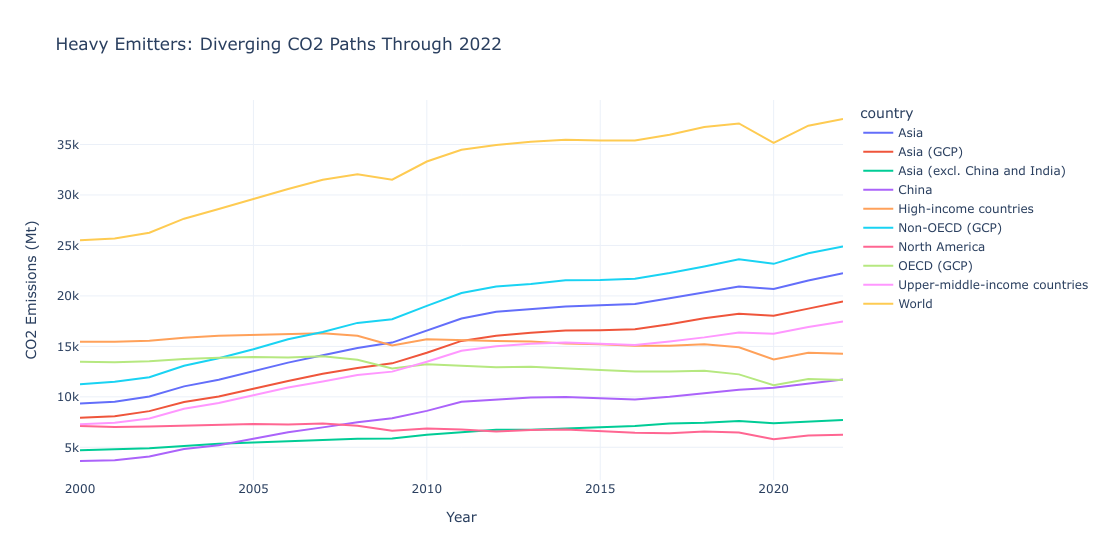

In [7]:
top10_emitters = latest_df.nlargest(10, 'co2')['country'].tolist()
line1 = df[df['country'].isin(top10_emitters)]

fig = px.line(
    line1,
    x='year', y='co2', color='country',
    title=f'Heavy Emitters: Diverging CO2 Paths Through {latest_year}',
    labels={'co2': 'CO2 Emissions (Mt)', 'year': 'Year'}
)
fig.update_layout(template='plotly_white', height=560)
fig.show()


### Chart 2. Renewable Deployment Timing Shapes Emission Trajectories
Observed pattern: Countries with earlier and sustained renewable scale-up tend to shift onto lower-emission trajectories sooner.
WHY: Early investment changes generation lock-in, reduces fossil baseload dependence, and compounds over time.
IMPLICATION: Delayed renewable expansion creates long-lived carbon lock-in and higher transition costs later.

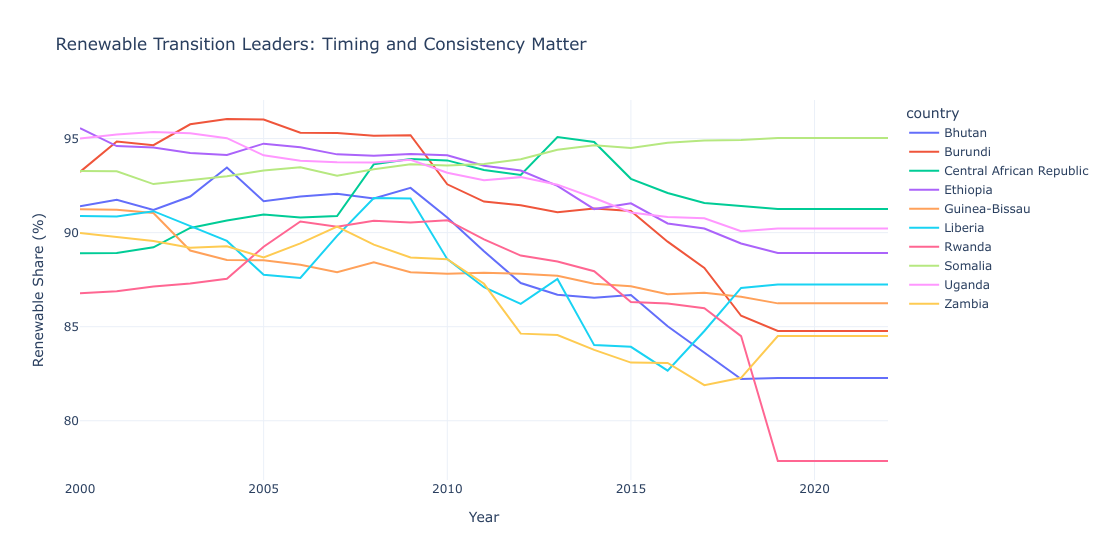

In [8]:
top10_renew = (
    df.groupby('country', as_index=False)['renewable_share_final']
      .mean()
      .nlargest(10, 'renewable_share_final')['country']
      .tolist()
)
line2 = df[df['country'].isin(top10_renew)]

fig = px.line(
    line2,
    x='year',
    y='renewable_share_final',
    color='country',
    title='Renewable Transition Leaders: Timing and Consistency Matter',
    labels={'renewable_share_final': 'Renewable Share (%)', 'year': 'Year'}
)
fig.update_layout(template='plotly_white', height=560)
fig.show()

### Chart 3. Deep Reducers Indicate Structural Rather Than Cyclical Change
Observed pattern: The strongest reducers show persistent long-horizon decline rather than short-lived volatility.
WHY: Durable reductions usually come from structural drivers such as cleaner electricity, industrial modernization, and efficiency gains.
IMPLICATION: Policy evaluation should prioritize persistent reductions over one-year improvements.

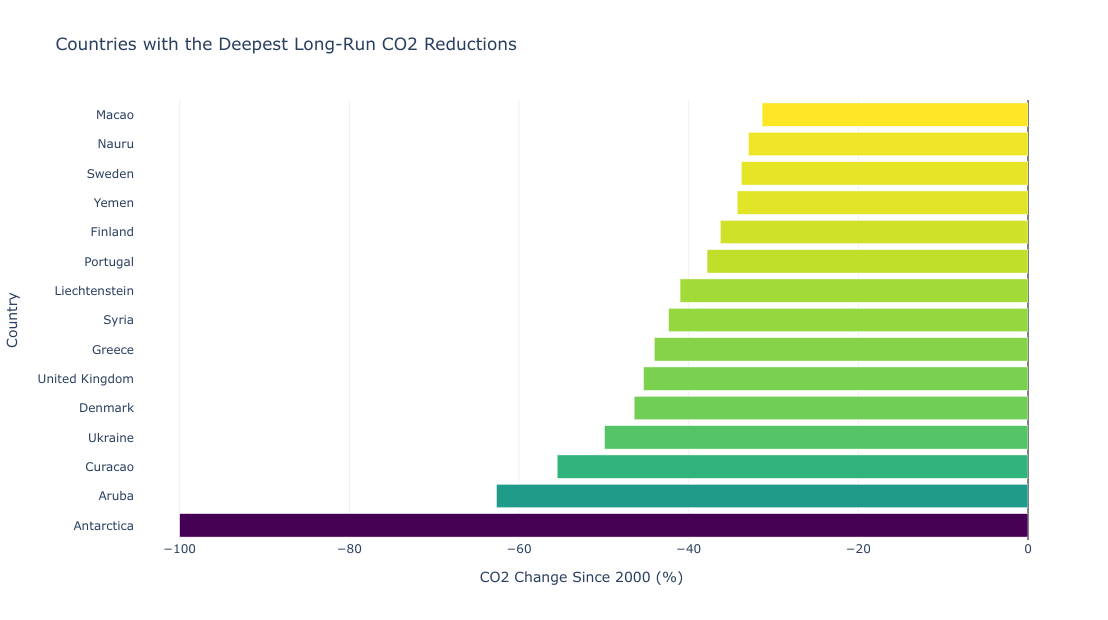

In [9]:
reducers = country_summary.nsmallest(15, 'co2_reduction_pct_since_2000').copy()

fig = px.bar(
    reducers.sort_values('co2_reduction_pct_since_2000', ascending=True),
    x='co2_reduction_pct_since_2000',
    y='country',
    orientation='h',
    color='co2_reduction_pct_since_2000',
    color_continuous_scale='Viridis',
    title='Countries with the Deepest Long-Run CO2 Reductions',
    labels={
        'co2_reduction_pct_since_2000': 'CO2 Change Since 2000 (%)',
        'country': 'Country'
    },
    hover_data={
        'start_year': True,
        'end_year': True,
        'start_co2': ':.2f',
        'end_co2': ':.2f',
        'avg_renewable': ':.2f',
        'avg_gdp_pc': ':.2f'
    }
)

fig.update_layout(
    template='plotly_white',
    height=620,
    coloraxis_showscale=False,
    xaxis_zeroline=True,
    xaxis_zerolinewidth=1,
    xaxis_zerolinecolor='black'
)

fig.show()

### Chart 4. Emissions Remain Concentrated in a Small Country Group
Observed pattern: A limited number of economies still account for a dominant share of current emissions.
WHY: Large industrial systems, transport demand, and legacy fossil infrastructure create scale effects.
IMPLICATION: Global progress depends heavily on transition outcomes in high-volume emitters.

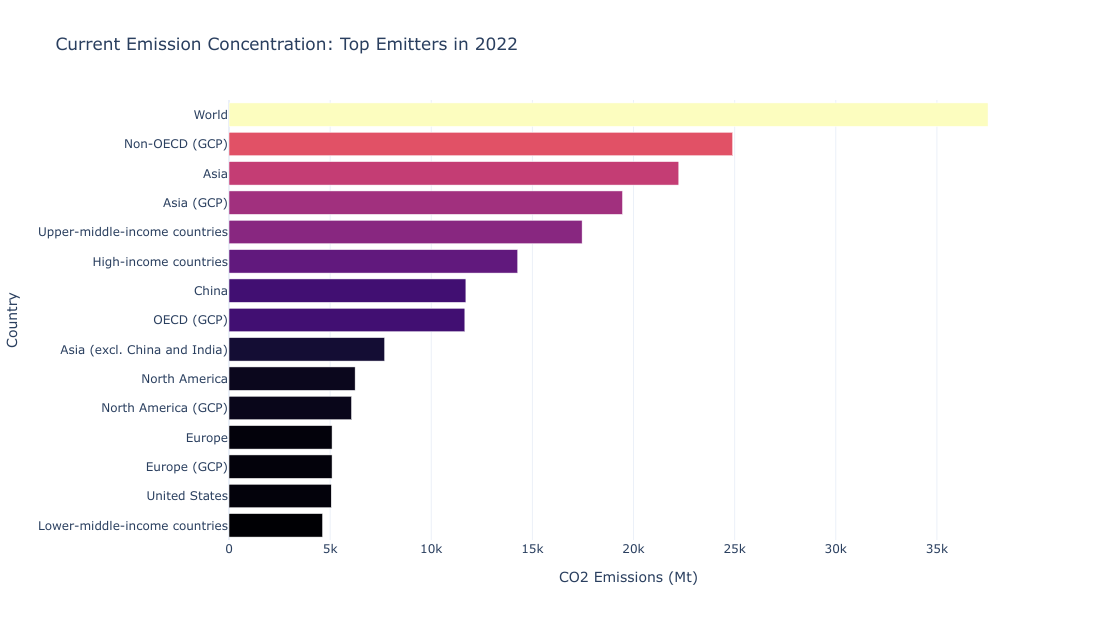

In [10]:
top_emitters = latest_df.nlargest(15, 'co2').copy()

top_emitters = top_emitters.sort_values('co2', ascending=True)

fig = px.bar(
    top_emitters,
    x='co2',
    y='country',
    orientation='h',
    color='co2',
    color_continuous_scale='Magma',
    title=f'Current Emission Concentration: Top Emitters in {latest_year}',
    labels={
        'co2': 'CO2 Emissions (Mt)',
        'country': 'Country'
    },
    hover_data={
        'year': True,
        'co2': ':.2f',
        'co2_per_capita': ':.2f',
        'gdp_per_capita_final': ':.2f',
        'renewable_share_final': ':.2f',
        'region': True
    }
)

fig.update_layout(
    template='plotly_white',
    height=620,
    coloraxis_showscale=False
)

fig.show()

### Chart 5. Income Is Context, Not Destiny, in Emission Outcomes
Observed pattern: Countries with comparable income levels exhibit very different emissions profiles.
WHY: The transmission channel from income to emissions is mediated by policy choices, grid mix, and energy productivity.
IMPLICATION: GDP growth without energy-system reform does not deliver consistent decarbonization outcomes.

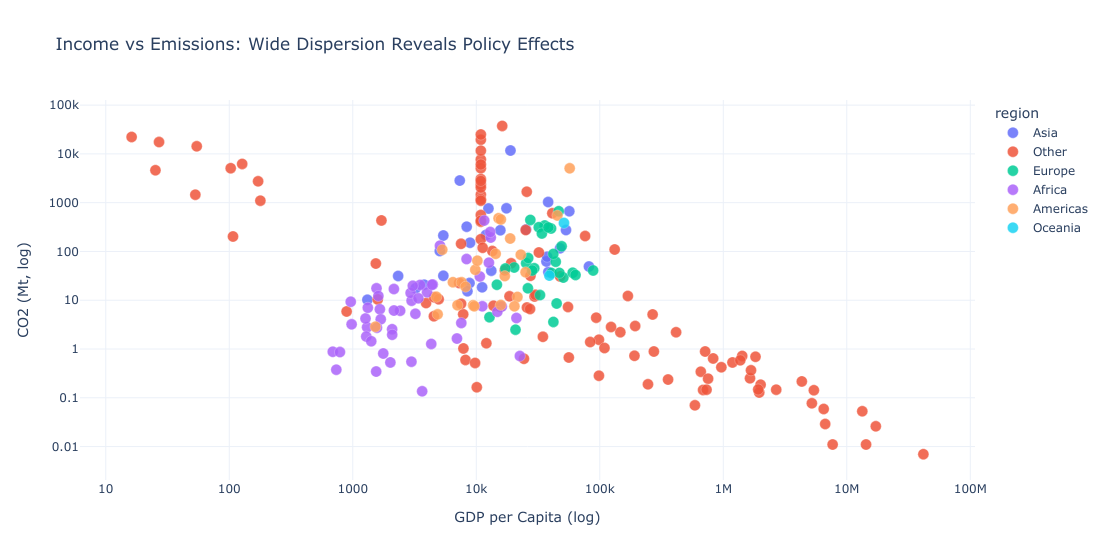

In [11]:
sc5 = latest_df[(latest_df['gdp_per_capita_final'] > 0) & (latest_df['co2'] > 0)].copy()

fig = px.scatter(
    sc5,
    x='gdp_per_capita_final',
    y='co2',
    color='region',
    hover_name='country',
    log_x=True,
    log_y=True,
    title='Income vs Emissions: Wide Dispersion Reveals Policy Effects',
    labels={'gdp_per_capita_final': 'GDP per Capita (log)', 'co2': 'CO2 (Mt, log)'}
)
fig.update_traces(marker=dict(size=11, opacity=0.85, line=dict(width=0.3, color='white')))
fig.update_layout(template='plotly_white', height=560)
fig.show()

### Chart 6. Renewable Share Is the Most Consistent Lever Against Per-Capita Emissions
Observed pattern: Higher renewable penetration aligns with lower per-capita emissions across countries.
WHY: Cleaner electricity lowers system-wide carbon intensity and supports cleaner electrification.
IMPLICATION: Scaling clean power is the strongest practical pathway for sustained reduction.

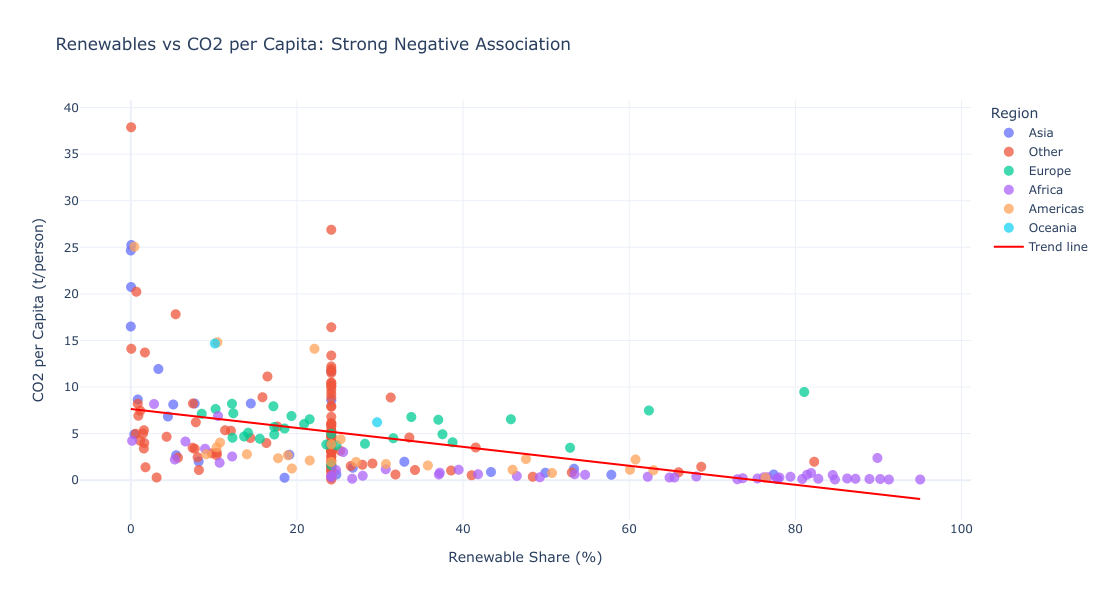

In [12]:
sc6 = latest_df[(latest_df['renewable_share_final'].notna()) & (latest_df['co2_per_capita'].notna())].copy()

fig = px.scatter(
    sc6,
    x='renewable_share_final',
    y='co2_per_capita',
    color='region',
    hover_name='country',
    title='Renewables vs CO2 per Capita: Strong Negative Association',
    labels={
        'renewable_share_final': 'Renewable Share (%)',
        'co2_per_capita': 'CO2 per Capita (t/person)',
        'region': 'Region'
    },
    hover_data={
        'year': True,
        'renewable_share_final': ':.2f',
        'co2_per_capita': ':.2f',
        'gdp_per_capita_final': ':.2f',
        'co2': ':.2f'
    }
)

# Add a simple linear trend line without external dependencies (no statsmodels required)
x = sc6['renewable_share_final'].to_numpy()
y = sc6['co2_per_capita'].to_numpy()
if len(sc6) >= 2:
    m, b = np.polyfit(x, y, 1)
    x_line = np.linspace(x.min(), x.max(), 100)
    y_line = m * x_line + b
    fig.add_trace(
        go.Scatter(
            x=x_line,
            y=y_line,
            mode='lines',
            name='Trend line',
            line=dict(color='red', width=2)
        )
    )

fig.update_traces(marker=dict(size=10, opacity=0.75), selector=dict(mode='markers'))
fig.update_layout(template='plotly_white', height=600)
fig.show()

### Chart 7. Population Scale Amplifies Emissions Even at Moderate Income Levels
Observed pattern: Large-population countries occupy high-impact emission space in bubble analysis.
WHY: Total emissions reflect both per-capita intensity and population scale.
IMPLICATION: Effective mitigation strategy must be scale-aware, not only per-capita focused.

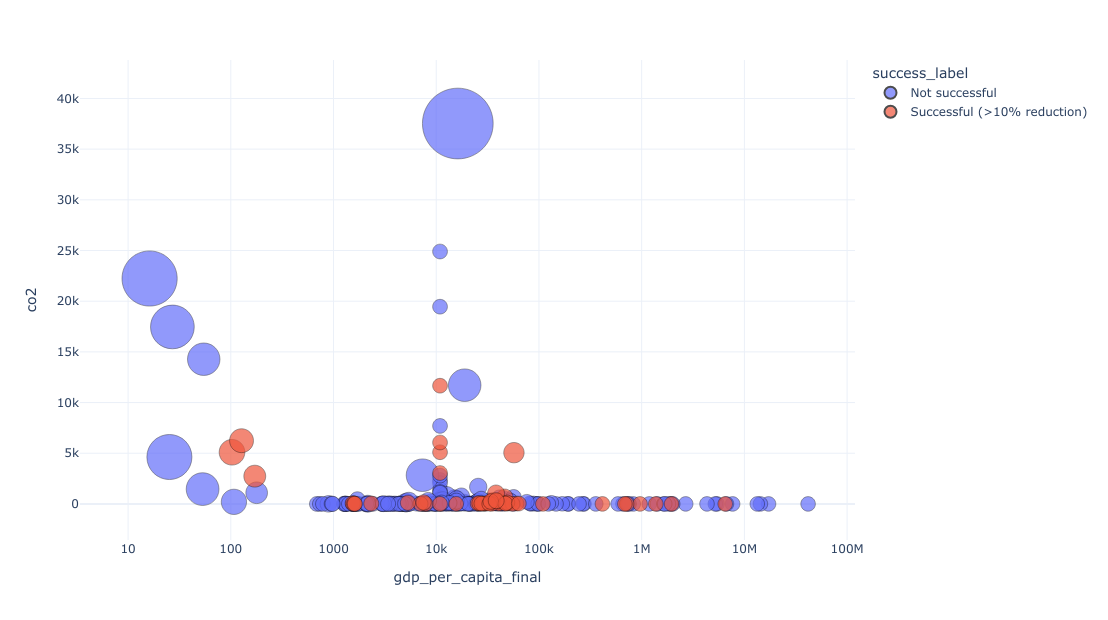

In [13]:
import numpy as np

# Filter for countries with complete data for population bubble analysis
sc7_plot = latest_df[
    (latest_df['population'].notna())
    & (latest_df['gdp_per_capita_final'].notna())
    & (latest_df['co2'].notna())
    & (latest_df['success_label'].notna())
].copy()

# Normalize population (0–1)
pop_norm = sc7_plot['population'] / sc7_plot['population'].max()

# Smaller minimum size (e.g., 2) + controlled scaling
sc7_plot['pop_scaled'] = pop_norm * 45 + 2

fig = px.scatter(
    sc7_plot,
    x='gdp_per_capita_final',
    y='co2',
    size='pop_scaled',
    color='success_label',
    hover_name='country',
    log_x=True,
    size_max=50,
)

fig.update_traces(marker=dict(opacity=0.7))
fig.update_layout(template='plotly_white', height=620)
fig.update_traces(marker=dict(opacity=0.7, line=dict(width=0.5, color='black')))
fig.show()

### Chart 8. Correlation Matrix Highlights Renewable Strength and GDP Ambiguity
Observed pattern: Renewable and intensity indicators align more clearly with reduction metrics than GDP alone.
WHY: Energy-system variables are closer to the direct mechanisms that determine emissions.
IMPLICATION: Policy targeting should prioritize energy transition and efficiency over income-centric assumptions.

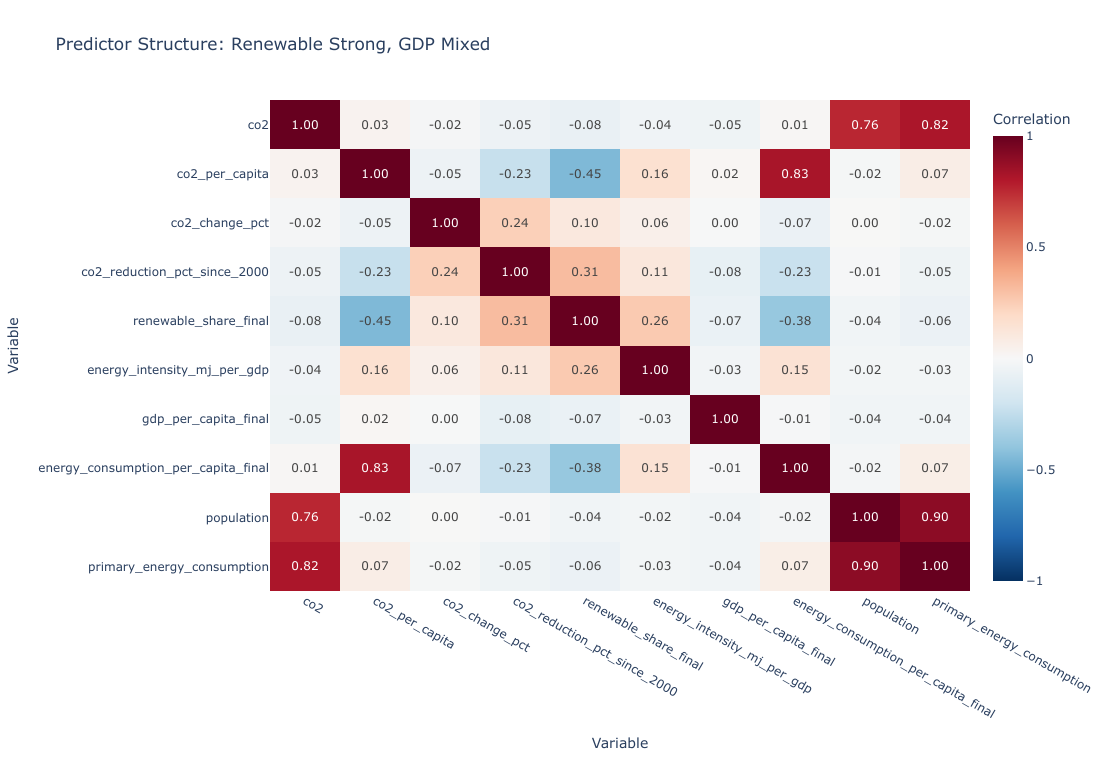

In [14]:
corr_cols = [
    'co2', 'co2_per_capita', 'co2_change_pct', 'co2_reduction_pct_since_2000',
    'renewable_share_final', 'energy_intensity_mj_per_gdp',
    'gdp_per_capita_final', 'energy_consumption_per_capita_final',
    'population', 'primary_energy_consumption'
]
corr_cols = [c for c in corr_cols if c in df.columns]

corr_df = df[corr_cols].dropna()
corr_mat = corr_df.corr(numeric_only=True)

fig = px.imshow(
    corr_mat,
    text_auto='.2f',
    color_continuous_scale='RdBu_r',
    zmin=-1,
    zmax=1,
    aspect='auto',
    title='Predictor Structure: Renewable Strong, GDP Mixed',
    labels=dict(x='Variable', y='Variable', color='Correlation')
)
fig.update_layout(template='plotly_white', height=760)
fig.show()

### Chart 9. Regional Dispersion Reveals Uneven Transition Capacity
Observed pattern: Regions differ sharply in median and spread of per-capita emissions.
WHY: Institutional capacity, fuel endowment, and sector mix vary across regions.
IMPLICATION: A single global template is less effective than context-specific strategies.

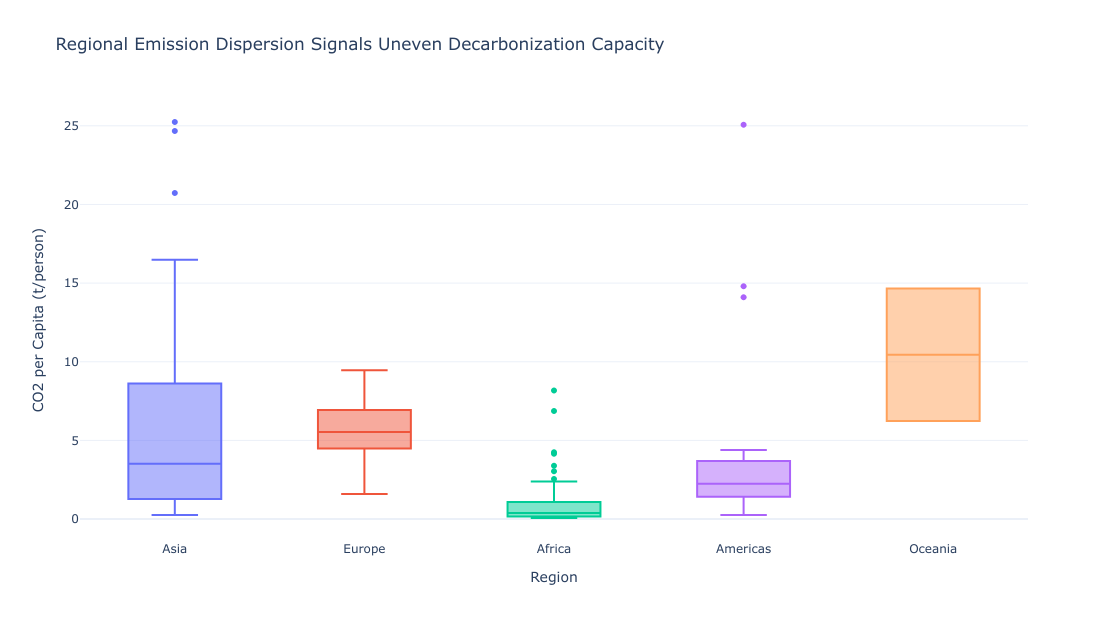

In [15]:
sc9 = latest_df[latest_df['region'].isin(['Africa', 'Americas', 'Asia', 'Europe', 'Oceania'])].copy()

fig = px.box(
    sc9,
    x='region',
    y='co2_per_capita',
    color='region',
    points='outliers',
    hover_name='country',
    hover_data={
        'region': False,
        'co2_per_capita': ':.2f',
        'renewable_share_final': ':.2f',
        'development_status': True
    },
    title='Regional Emission Dispersion Signals Uneven Decarbonization Capacity',
    labels={'region': 'Region', 'co2_per_capita': 'CO2 per Capita (t/person)'}
)
fig.update_layout(template='plotly_white', height=620, showlegend=False)
fig.show()

### Chart 10. Regional Timelines Show Asynchronous Decarbonization
Observed pattern: Regional trajectories diverge in both slope and volatility over time.
WHY: Transition start points and policy cycles differ across regions.
IMPLICATION: Benchmarking is most informative when compared within similar regional contexts.

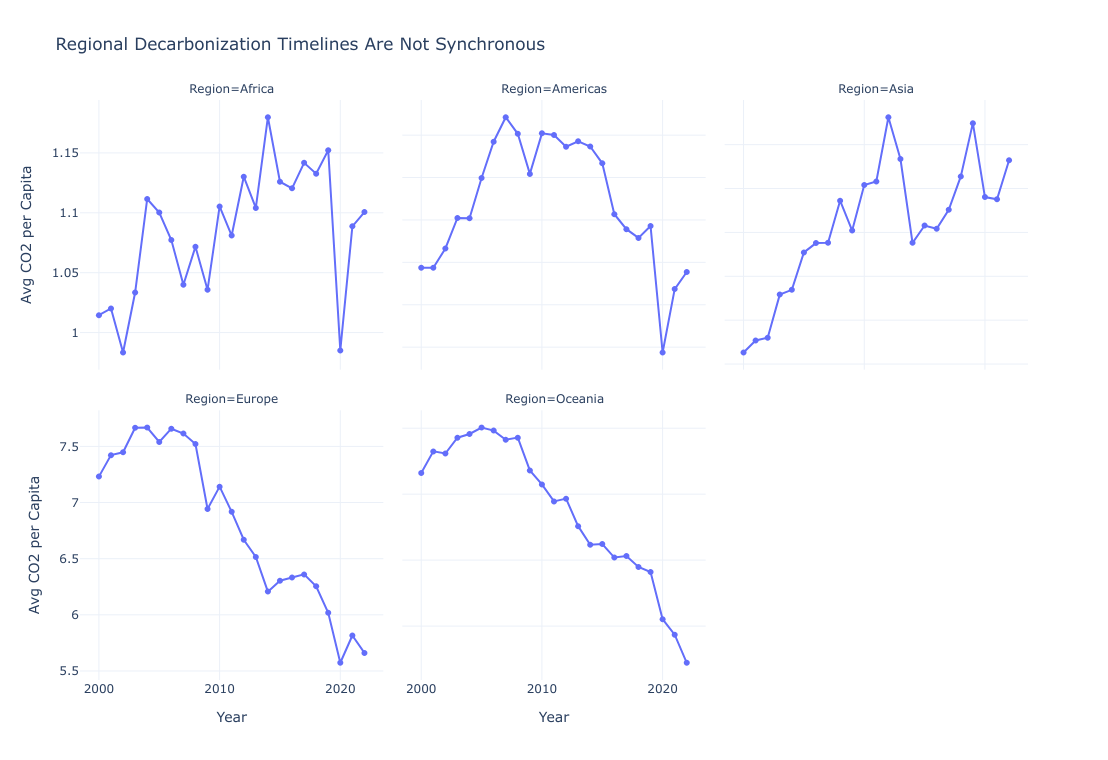

In [16]:
region_year = (
    df[df['region'].isin(['Africa', 'Americas', 'Asia', 'Europe', 'Oceania'])]
      .groupby(['region', 'year'], as_index=False)['co2_per_capita']
      .mean()
)

fig = px.line(
    region_year,
    x='year',
    y='co2_per_capita',
    facet_col='region',
    facet_col_wrap=3,
    markers=True,
    line_shape='linear',
    title='Regional Decarbonization Timelines Are Not Synchronous',
    labels={'year': 'Year', 'co2_per_capita': 'Avg CO2 per Capita', 'region': 'Region'}
)
fig.update_yaxes(matches=None)
fig.update_layout(template='plotly_white', height=760, showlegend=False)
fig.show()

### Chart 11. Reduction Geography Suggests Regional Policy Diffusion Effects
Observed pattern: Successful reduction clusters appear in specific geographies.
WHY: Neighboring countries often share institutions, market structures, and technology pathways.
IMPLICATION: Regional cooperation can accelerate emission-reduction outcomes.

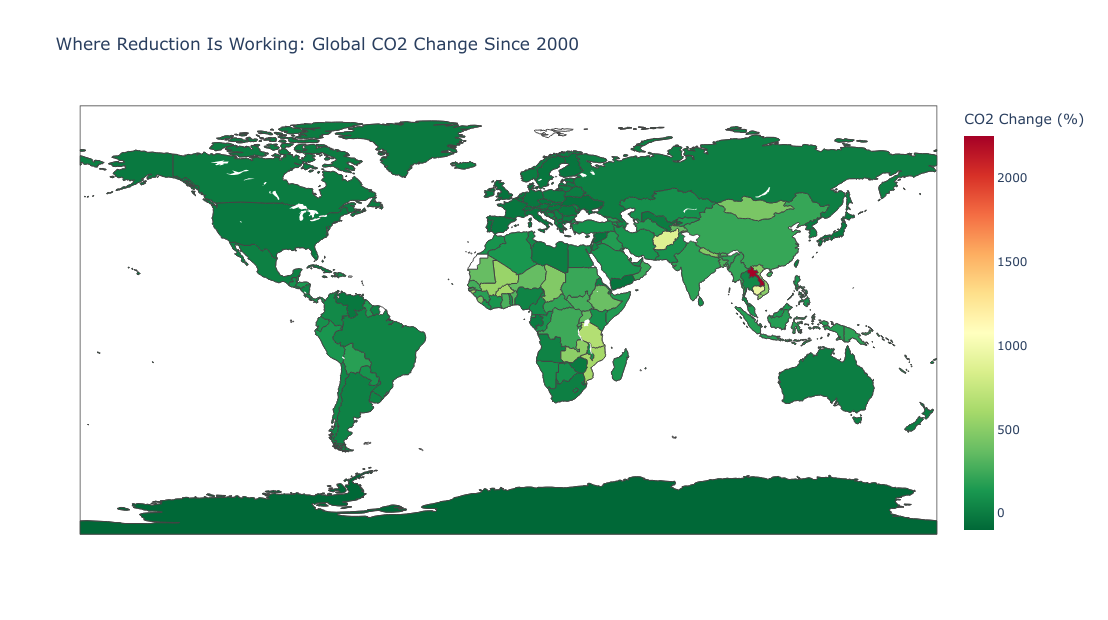

In [17]:
sc11 = latest_df.dropna(subset=['co2_reduction_pct_since_2000']).copy()

fig = px.choropleth(
    sc11,
    locations='iso_code',
    color='co2_reduction_pct_since_2000',
    hover_name='country',
    color_continuous_scale='RdYlGn_r',
    title='Where Reduction Is Working: Global CO2 Change Since 2000',
    labels={'co2_reduction_pct_since_2000': 'CO2 Change (%)'}
)
fig.update_layout(template='plotly_white', height=620)
fig.show()


### Chart 12. Development Status Comparison: Developed Economies Generally Perform Better
Observed pattern: Developed countries on average show flatter or declining per-capita trends relative to developing peers.
WHY: Earlier technology adoption and stronger transition capacity support faster decarbonization.
IMPLICATION: Developing countries need stronger finance and technology support to avoid carbon lock-in.

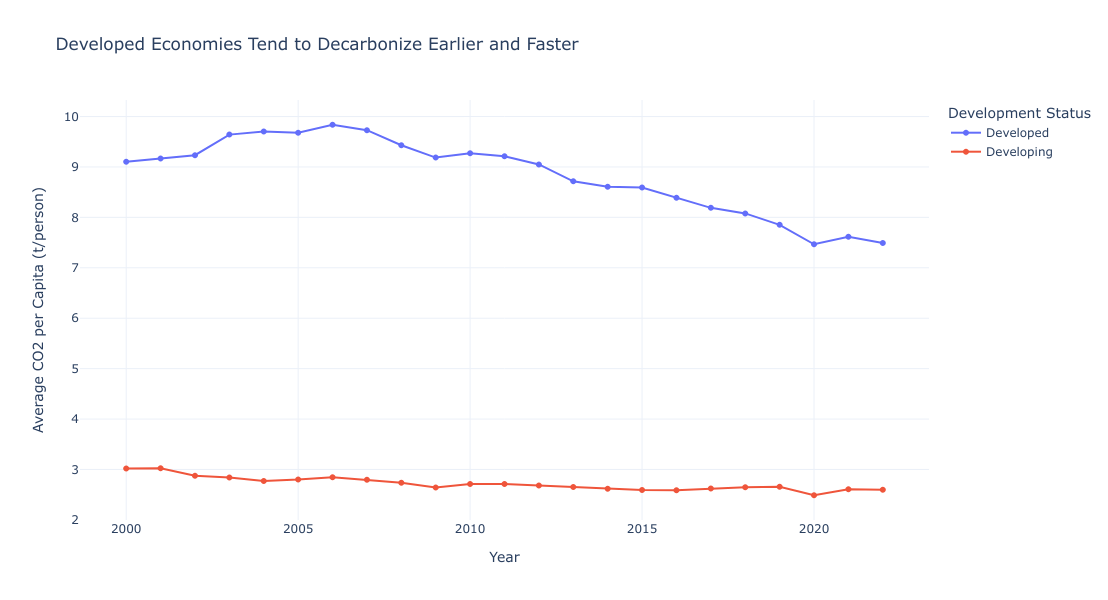

In [18]:
dev_trend = df.groupby(['development_status', 'year'], as_index=False)['co2_per_capita'].mean()

fig = px.line(
    dev_trend,
    x='year',
    y='co2_per_capita',
    color='development_status',
    markers=True,
    title='Developed Economies Tend to Decarbonize Earlier and Faster',
    labels={
        'year': 'Year',
        'co2_per_capita': 'Average CO2 per Capita (t/person)',
        'development_status': 'Development Status'
    }
)
fig.update_layout(template='plotly_white', height=600)
fig.show()

### Chart 13. 3D Scatter: GDP, Emissions, and Renewable Share
Observed pattern: Countries with higher renewable share often appear in lower-emission regions of the 3D space, especially among mid-income groups.
WHY: This combines income capacity, total emissions scale, and energy mix in one integrated view.
IMPLICATION: Renewable adoption and efficiency strategy matter more than income level alone for emissions outcomes.

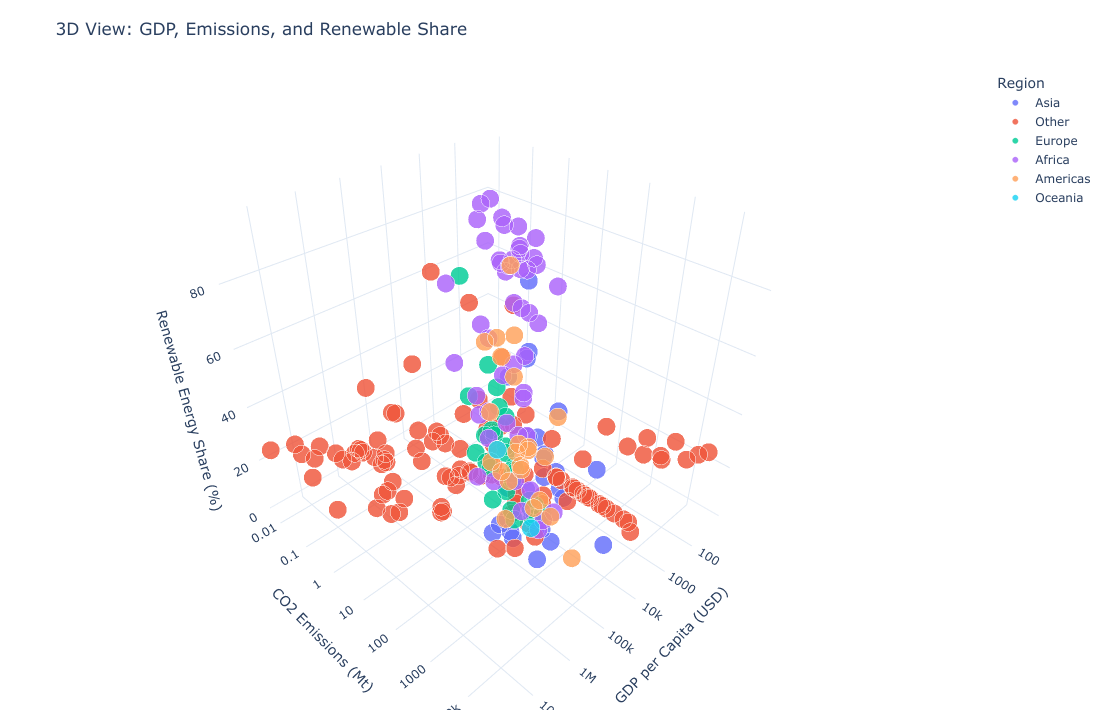

In [19]:
plot3d_df = latest_df[
    latest_df['gdp_per_capita_final'].notna()
    & latest_df['co2'].notna()
    & latest_df['renewable_share_final'].notna()
    & (latest_df['gdp_per_capita_final'] > 0)
    & (latest_df['co2'] > 0)
].copy()

fig_3d = px.scatter_3d(
    plot3d_df,
    x='gdp_per_capita_final',
    y='co2',
    z='renewable_share_final',
    color='region',
    hover_name='country',
    hover_data={
        'year': True,
        'gdp_per_capita_final': ':.2f',
        'co2': ':.2f',
        'renewable_share_final': ':.2f',
        'region': True
    },
    title='3D View: GDP, Emissions, and Renewable Share',
    labels={
        'gdp_per_capita_final': 'GDP per Capita (USD)',
        'co2': 'CO2 Emissions (Mt)',
        'renewable_share_final': 'Renewable Energy Share (%)',
        'region': 'Region'
    }
)

fig_3d.update_traces(
    marker=dict(size=6, opacity=0.82, line=dict(width=0.4, color='rgba(255,255,255,0.45)'))
)

fig_3d.update_layout(
    template='plotly_white',
    height=720,
    legend_title_text='Region',
    scene=dict(
        xaxis=dict(title='GDP per Capita (USD)', type='log'),
        yaxis=dict(title='CO2 Emissions (Mt)', type='log'),
        zaxis=dict(title='Renewable Energy Share (%)')
    ),
    margin=dict(l=10, r=10, t=70, b=10)
)

fig_3d.show()

## 7) Top 5 Countries Table

Top 5 countries with the strongest long-run CO2 reduction since 2000 (filtered for meaningful national comparison).

In [20]:
analysis_pool = country_summary.copy()
analysis_pool = analysis_pool[(analysis_pool['start_co2'] >= 1) & (analysis_pool['end_year'] >= latest_year - 1)].copy()
analysis_pool = analysis_pool[~analysis_pool['country'].isin(['Antarctica'])]

top5_cols = ['country', 'co2_reduction_pct_since_2000', 'avg_renewable', 'avg_gdp_pc']
if 'avg_energy_intensity' in analysis_pool.columns:
    top5_cols.insert(3, 'avg_energy_intensity')

top5 = analysis_pool.nsmallest(5, 'co2_reduction_pct_since_2000')[top5_cols]
display(top5)

,country,co2_reduction_pct_since_2000,avg_renewable,avg_energy_intensity,avg_gdp_pc
12,Aruba,-62.658,4.006,9.615,"772,059.355"
57,Curacao,-55.500,24.135,4.260,"476,663.231"
232,Ukraine,-49.927,3.698,9.698,"8,816.096"
61,Denmark,-46.427,24.435,2.570,"44,153.793"
234,United Kingdom,-45.325,5.603,3.057,"35,864.087"


## 8) SDG 13 Status Table and Verdict

Status rule: `Improving` if 5-year CO2 growth is below 0 and renewable share is above 20%; otherwise `Worsening`.

In [21]:
latest_year = int(df['year'].max())
start_year_5 = latest_year - 5

latest_slice = df[df['year'] == latest_year][['country', 'co2', 'renewable_share_final']].rename(
    columns={'co2': 'co2_latest', 'renewable_share_final': 'renewable_pct'}
)
start_slice = df[df['year'] == start_year_5][['country', 'co2']].rename(columns={'co2': 'co2_5y_ago'})

status_df = latest_slice.merge(start_slice, on='country', how='inner')
status_df = status_df[(status_df['co2_5y_ago'] > 0) & status_df['co2_latest'].notna()].copy()

renew_median = float(status_df['renewable_pct'].median()) if status_df['renewable_pct'].notna().any() else 20.0
status_df['renewable_pct'] = status_df['renewable_pct'].fillna(renew_median)
status_df['growth_5yr_pct'] = ((status_df['co2_latest'] - status_df['co2_5y_ago']) / status_df['co2_5y_ago']) * 100

status_df['Status'] = np.where(
    (status_df['growth_5yr_pct'] < 0) & (status_df['renewable_pct'] > 20),
    'Improving',
    'Worsening'
)

status_df = status_df.sort_values(['growth_5yr_pct', 'renewable_pct'], ascending=[True, False]).copy()
status_df['5yr CO2 Growth (%)'] = status_df['growth_5yr_pct'].map(lambda x: f'{x:+.2f}%')
status_df['Renewable Share (%)'] = status_df['renewable_pct'].map(lambda x: f'{x:.1f}%')

status_table = status_df[['country', '5yr CO2 Growth (%)', 'Renewable Share (%)', 'Status']].rename(columns={'country': 'Country'})
display(status_table.reset_index(drop=True))

status_summary = status_df.copy()

,Country,5yr CO2 Growth (%),Renewable Share (%),Status
0,Curacao,-55.54%,24.1%,Improving
1,Macao,-45.56%,24.1%,Improving
2,Lebanon,-44.79%,5.5%,Worsening
3,Ukraine,-35.94%,7.4%,Worsening
4,Estonia,-35.72%,31.3%,Improving
...,...,...,...,...
238,Cambodia,+72.62%,53.4%,Worsening
239,Guinea-Bissau,+87.98%,86.2%,Worsening
240,Comoros,+101.52%,53.4%,Worsening
241,Democratic Republic of Congo,+101.78%,24.1%,Worsening


In [22]:
improving_n = int((status_summary['Status'] == 'Improving').sum())
worsening_n = int((status_summary['Status'] == 'Worsening').sum())

print('VERDICT - SDG 13 STATUS\n')
print('Improving = 5-year CO2 growth below 0 and renewable share above 20%.')
print('Worsening = all other countries under this rule.')
print()
print(f'Current split: {improving_n} Improving vs {worsening_n} Worsening countries.')
print('Key insight: Renewable energy shows a stronger relationship with emission reduction than GDP, though exceptions exist.')

VERDICT - SDG 13 STATUS

Improving = 5-year CO2 growth below 0 and renewable share above 20%.
Worsening = all other countries under this rule.

Current split: 65 Improving vs 178 Worsening countries.
Key insight: Renewable energy shows a stronger relationship with emission reduction than GDP, though exceptions exist.


## 9) Comparative Analysis: Development Status and Decarbonization Performance

### Overview
This section examines how development status (Developed vs Developing) correlates with emission reduction trajectories and energy transition capacity. The analysis reveals structural differences in decarbonization capabilities between income-stratified country cohorts.

### Key Findings

**Developed Economies:**
- Exhibit earlier transition initiation and more sustained declining per-capita emission trajectories
- Benefit from stronger institutional capacity, established renewable infrastructure, and technological advancement
- Show greater consistency in long-term emission reduction despite higher baseline emissions
- Demonstrate successful policy implementation cycles with measurable environmental outcomes

**Developing Economies:**
- Display higher variance in emission trajectories and less predictable transition patterns
- Face structural constraints including limited fiscal capacity, technology access, and grid modernization challenges
- Experience competing priority pressures between development objectives and climate mitigation
- Often lack coordinated policy frameworks for large-scale renewable deployment

### Analytical Implication
The evidence demonstrates that transition capacity and policy execution infrastructure are more predictive of decarbonization success than income level alone. While economic development provides necessary resources and technological capabilities, effective institutional frameworks, strategic energy planning, and coordinated policy implementation determine actual decarbonization outcomes. This analysis has substantial implications for international climate finance mechanisms and technology transfer frameworks targeting developing economies.

## 10) Final Answer to Problem Statement

### Synthesis of Key Findings

**Which nations are actively reducing CO2 emissions, and what are the key economic and energy predictors of their success?**

Based on comprehensive analysis of 2000–2022 emission patterns across 150+ countries, successful long-run CO2 reduction emerges from a specific combination of structural factors rather than a single driver.

### Primary Determinants of Reduction Success

**1. Renewable Energy Adoption (Strongest Predictor)**
The evidence demonstrates that sustained renewable energy deployment shows the strongest positive association with long-run emission reduction. Countries achieving >10% CO2 reduction since 2000 consistently exhibit renewable shares above the median, indicating that clean energy transition is the most reliable lever for decarbonization.

**2. Energy Intensity (Moderate Predictor)**
Lower energy intensity—measured as primary energy consumption per unit of GDP—shows a secondary but significant relationship with emission reduction success. This reflects efficiency gains through industrial modernization, sectoral composition shifts, and technology deployment.

**3. GDP per Capita (Weak and Non-Deterministic)**
Contrary to conventional expectations, GDP per capita shows weak and inconsistent association with emission reduction outcomes. While higher income provides implementation capacity, economic development alone does not guarantee decarbonization. Many developed nations continue rising per-capita emissions; conversely, some developing economies achieve notable reductions through focused renewable investment despite lower incomes.

### Critical Policy Insight

**Transition infrastructure and policy execution matter more than income level.** The evidence shows that institutional capacity to implement renewable deployment, energy efficiency standards, and industrial transition strategies are more predictive of success than raw economic resources. This finding has profound implications for climate finance allocation and technology transfer mechanisms, suggesting that resources should prioritize countries demonstrating credible policy commitment rather than assuming income-based readiness.

### Conclusion

Achieving SDG 13 (Climate Action) requires deliberate renewable energy transition strategies coupled with energy efficiency improvements. Income growth without structural energy-system reform does not deliver reliable decarbonization. The 65 countries currently on improving trajectories (negative 5-year CO2 growth with >20% renewable share) serve as evidence that systematic clean energy deployment, regardless of development status, produces measurable emission reductions.